## NISAR GSLC Data <img align="right" src="../../resources/csiro_easi_logo.png">

#### Index
- [Overview](#Overview)
- [Setup (imports, authentication, S3)](#Setup)
- [Discover GSLC scenes](#Discover-GSLC-scenes)
- [Explore HDF5 structure](#Explore-HDF5-structure)
- [Load GSLC data](#Load-GSLC-data)
- [Amplitude and Phase visualisation](#Amplitude-and-Phase-visualisation)
- [Interferogram](#Interferogram)
- [Export to GeoTIFF](#Export-to-GeoTIFF)

### Overview

The **NASA-ISRO Synthetic Aperture Radar (NISAR)** mission is a joint Earth-observing mission between NASA and the Indian Space Research Organisation (ISRO). Launched in 2024, NISAR carries dual-frequency SAR instruments operating at **L-band** (NASA's LSAR) and **S-band** (ISRO's SSAR), enabling global measurements of surface deformation, ecosystem change, and ice dynamics.

The **Geocoded Single Look Complex (GSLC)** product is a Level-2 product that provides the full complex-valued SAR signal (amplitude and phase) geocoded onto a map grid. Unlike detected (intensity) products, GSLC preserves the phase information essential for **interferometric SAR (InSAR)** applications such as:
- Surface displacement monitoring (earthquakes, volcanoes, subsidence)
- Digital elevation model generation
- Coherence-based land cover classification

GSLC data is distributed in **HDF5** format via the [Alaska Satellite Facility (ASF) DAAC](https://asf.alaska.edu/). JPL has released over 100,000 NISAR data product files — see the [ASF announcement](https://asf.alaska.edu/notices/jpl-releases-over-100k-new-nisar-data-product-files/).

| Field | Value |
|-------|-------|
| Mission | NISAR (NASA-ISRO SAR) |
| Product | GSLC (Geocoded Single Look Complex) |
| Level | Level-2 |
| Format | HDF5 |
| Bands | L-band (LSAR), S-band (SSAR) |
| Polarisations | HH, HV (default); quad-pol available |
| Resolution | ~7 m (range) × ~12 m (azimuth) |
| Distribution | ASF DAAC (NASA Earthdata) |
| Access | S3 in `us-west-2`, HTTPS via `earthaccess` |

> **Note:** Unlike other notebooks in this series, GSLC data is accessed directly via HDF5 using `h5py` and `earthaccess`, rather than through ODC `dc.load()`. This is because the data is complex-valued and stored in HDF5 — a format not natively indexed in ODC.

---
### Setup

#### Imports

If any of the packages below are not available, refer to the [adding-python-libraries](../adding-python-libraries.ipynb) notebook for installation instructions. Key additional packages for this notebook: `earthaccess`, `h5py`, `rioxarray`.

In [3]:
# Common imports
import os, sys
from pathlib import Path
from IPython.display import Markdown, display

import numpy as np
import xarray as xr

# HDF5 and S3 access
import h5py
import earthaccess

# Plots
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [6]:
# Lightweight heading utility (avoids pulling in datacube/geopandas via easi_tools)
def heading(text):
    """Display a styled heading — mirrors easi_tools.heading()"""
    display(Markdown(f'**{text}**'))

#### Earthdata authentication

NISAR data is distributed by the ASF DAAC and requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account.

The `earthaccess` library handles authentication, token refresh, and S3 credential vending. On first use it will prompt for your Earthdata username and password. Credentials can be persisted in a `.netrc` file — see the [earthaccess documentation](https://earthaccess.readthedocs.io/).

In [7]:
auth = earthaccess.login()
print(f'Authenticated as: {auth.username if hasattr(auth, "username") else "OK"}')

Authenticated as: tisham_csiro


#### S3 / HTTPS access

ASF hosts NISAR data in S3 (`us-west-2`). When running **inside AWS us-west-2** (e.g., on an EASI hub), `earthaccess` provides direct S3 access for maximum throughput. When running **outside AWS**, it transparently falls back to HTTPS.

> **Note:** NISAR GSLC files are 15–23 GB each. We use `h5py` with cloud-aware file objects to read only the subsets we need, avoiding full downloads.

In [16]:
# earthaccess.open() handles S3 (in-region) or HTTPS (out-of-region) transparently
print('Access method will be determined when files are opened (S3 in us-west-2, HTTPS otherwise)')

Access method will be determined when files are opened (S3 in us-west-2, HTTPS otherwise)


---
### Discover GSLC scenes

We search for NISAR L-band GSLC granules using `earthaccess.search_data()`. The search queries NASA's Common Metadata Repository (CMR).

For this example, we select a region in **Southern California** (near the San Andreas Fault) — an area with abundant NISAR coverage and geological significance for InSAR analysis.

In [11]:
# Search parameters
SHORT_NAME = 'NISAR_L2_GSLC_BETA_V1'  # NISAR L-band GSLC (beta) collection
BBOX = (-118.0, 34.0, -117.0, 35.0)   # (west, south, east, north) — Southern California
TIME_RANGE = ('2025-06-01', '2026-03-01')  # Adjust based on data availability

heading('Searching for NISAR GSLC granules...')
results = earthaccess.search_data(
    short_name=SHORT_NAME,
    bounding_box=BBOX,
    temporal=TIME_RANGE,
    count=20
)
print(f'Found {len(results)} granules')

**Searching for NISAR GSLC granules...**

Found 19 granules


> **Tip:** If no results are found, try broadening the time range or bounding box. NISAR data availability varies by region and orbital cycle. Check [ASF Vertex](https://search.asf.alaska.edu/) for current coverage.
>
> You can also substitute the `SHORT_NAME` above. Other NISAR collections include:
> - `NISAR_L2_GSLC_V1` — L-band GSLC
> - `NISAR_L1_RSLC_V1` — L-band Radar-geometry SLC (non-geocoded)

In [12]:
# Display granule metadata
import pandas as pd

if results:
    rows = []
    for r in results[:10]:
        links = r.data_links(access='direct')
        h5_links = [l for l in links if l.endswith('.h5')]
        fname = h5_links[0].split('/')[-1] if h5_links else 'N/A'
        rows.append({
            'Granule': fname[:70],
            'Size (GB)': f'{r.size() / 1024:.1f}',
        })
    display(pd.DataFrame(rows))
else:
    print('No granules found — adjust search parameters above')

,Granule,Size (GB)
0,NISAR_L2_PR_GSLC_003_085_D_071_4005_DHDH_A_202...,14.7
1,NISAR_L2_PR_GSLC_004_085_D_071_4005_DHDH_A_202...,14.5
2,NISAR_L2_PR_GSLC_005_085_D_071_4005_DHDH_A_202...,14.6
3,NISAR_L2_PR_GSLC_006_085_D_071_4005_DHDH_A_202...,22.4
4,NISAR_L2_PR_GSLC_006_085_D_072_4005_DHDH_A_202...,20.3
5,NISAR_L2_PR_GSLC_007_034_A_018_4005_DHDH_A_202...,21.2
6,NISAR_L2_PR_GSLC_007_034_A_019_4005_DHDH_A_202...,21.2
7,NISAR_L2_PR_GSLC_007_085_D_071_4005_DHDH_A_202...,22.9
8,NISAR_L2_PR_GSLC_007_085_D_072_4005_DHDH_A_202...,20.9
9,NISAR_L2_PR_GSLC_008_013_D_071_0005_NADV_A_202...,2.5


In [17]:
# Select two granules for this example
# Two scenes over the same area on different dates are needed for the interferogram section.
# We pick the first two results (same frame/track, different repeat cycles).
assert len(results) >= 2, (
    f'Need at least 2 granules for interferogram demo, found {len(results)}. '
    'Broaden the search parameters.'
)

granule_1 = results[0]
granule_2 = results[1]

# Display the selected granule names
for i, g in enumerate([granule_1, granule_2], 1):
    links = g.data_links(access='direct')
    h5_links = [l for l in links if l.endswith('.h5')]
    print(f'Scene {i}: {h5_links[0].split("/")[-1]}')

Scene 1: NISAR_L2_PR_GSLC_003_085_D_071_4005_DHDH_A_20251023T023214_20251023T023240_X05010_N_P_J_001.h5
Scene 2: NISAR_L2_PR_GSLC_004_085_D_071_4005_DHDH_A_20251104T023215_20251104T023240_X05010_N_P_J_001.h5


---
### Explore HDF5 structure

NISAR GSLC files are HDF5 containers with a hierarchical group structure. Let's open one and inspect its contents.

In [20]:
def print_h5_tree(group, indent=0, max_depth=5):
    """Recursively print the HDF5 group/dataset tree."""
    if indent // 2 >= max_depth:
        return
    for key in group:
        item = group[key]
        prefix = '  ' * indent
        if isinstance(item, h5py.Group):
            print(f'{prefix}📁 {key}/')
            print_h5_tree(item, indent + 2, max_depth)
        elif isinstance(item, h5py.Dataset):
            shape_str = str(item.shape)
            dtype_str = str(item.dtype)
            print(f'{prefix}📄 {key}  [{shape_str}, {dtype_str}]')
        else:
            print(f'{prefix}❓ {key}')

In [21]:
heading('Opening GSLC HDF5 file (Scene 1)...')

# Open HDF5 via earthaccess (handles S3 or HTTPS transparently)
file_objs = earthaccess.open([granule_1])
f1 = h5py.File(file_objs[0], 'r')

links_1 = granule_1.data_links(access='direct')
fname_1 = [l for l in links_1 if l.endswith('.h5')][0].split('/')[-1]
print(f'File: {fname_1}\n')
print_h5_tree(f1, max_depth=5)

**Opening GSLC HDF5 file (Scene 1)...**

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 2966.27it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:02<00:00,  2.50s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 19065.02it/s]


File: NISAR_L2_PR_GSLC_003_085_D_071_4005_DHDH_A_20251023T023214_20251023T023240_X05010_N_P_J_001.h5

❓ complex64
📁 science/
    📁 LSAR/
        📁 GSLC/
            📁 grids/
                📁 frequencyA/
                📁 frequencyB/
            📁 metadata/
                📁 attitude/
                📁 calibrationInformation/
                📁 ceosAnalysisReadyData/
                📁 orbit/
                📁 processingInformation/
                📁 radarGrid/
                📁 sourceData/
        📁 identification/
            📄 absoluteOrbitNumber  [(), uint32]
            📄 boundingPolygon  [(), |S2128]
            📄 compositeReleaseId  [(), |S6]
            📄 diagnosticModeFlag  [(), uint32]
            📄 frameNumber  [(), uint16]
            📄 granuleId  [(), |S91]
            📄 instrumentName  [(), |S4]
            📄 isDithered  [(), |S4]
            📄 isFullFrame  [(), |S5]
            📄 isGeocoded  [(), |S4]
            📄 isJointObservation  [(), |S4]
            📄 isMixedMode  [

#### NISAR GSLC HDF5 layout

The typical group structure for L-band data is:

```
/science/LSAR/GSLC/
├── grids/
│   ├── frequencyA/              # L-band frequency A
│   │   ├── HH                   # Complex SLC data (complex64, chunked 512×512) — co-pol
│   │   ├── HV                   # Complex SLC data (complex64, chunked 512×512) — cross-pol
│   │   ├── mask                 # Valid pixel mask (uint8)
│   │   ├── xCoordinates         # X (easting) 1D coordinate array
│   │   ├── yCoordinates         # Y (northing) 1D coordinate array
│   │   ├── xCoordinateSpacing   # Grid spacing in X (e.g., 5.0 m)
│   │   ├── yCoordinateSpacing   # Grid spacing in Y (e.g., -5.0 m)
│   │   └── projection           # EPSG code + CRS attributes
│   └── frequencyB/              # S-band (if dual-frequency)
├── metadata/
│   ├── orbit/                   # Satellite state vectors
│   ├── attitude/                # Satellite attitude data
│   └── processingInformation/
└── identification/              # Scene ID, bounding polygon, timestamps
```

The SLC datasets are **complex-valued** (`complex64`): each pixel stores amplitude (backscatter strength) and phase (related to range distance and surface properties). A typical scene is ~68,000 × 70,000 pixels at 5 m spacing.

> Since these arrays are many GB each, we read only a **spatial subset** (window) for demonstration. The HDF5 chunking (512×512 with gzip) makes partial reads efficient.

---
### Load GSLC data

We read the complex SLC data for one polarisation channel and build an `xarray.DataArray` with spatial coordinates.

In [22]:
# Navigate to the GSLC grids
# Adapt the path if your granule has a different structure
GRID_BASE = 'science/LSAR/GSLC/grids/frequencyA'

# List available polarisation channels
grid_group = f1[GRID_BASE]
pol_channels = [k for k in grid_group.keys() if k in ('HH', 'HV', 'VH', 'VV', 'RH', 'RV')]
print(f'Available polarisation channels: {pol_channels}')

# Select primary channel
POL = pol_channels[0]  # Typically 'HH'
slc_dataset = grid_group[POL]
print(f'Selected: {POL}')
print(f'Full array shape: {slc_dataset.shape} ({slc_dataset.dtype})')
print(f'Chunk size: {slc_dataset.chunks}')
print(f'Full array size: {slc_dataset.shape[0] * slc_dataset.shape[1] * 8 / 1e9:.1f} GB')

# Read projection info
epsg = int(grid_group['projection'].attrs.get('epsg_code', 0))
x_spacing = float(grid_group['xCoordinateSpacing'][()])
y_spacing = float(grid_group['yCoordinateSpacing'][()])
print(f'CRS: EPSG:{epsg}, spacing: {x_spacing} m × {y_spacing} m')

Available polarisation channels: ['HH', 'HV']
Selected: HH
Full array shape: (68544, 69696) (complex64)
Chunk size: (512, 512)
Full array size: 38.2 GB
CRS: EPSG:32611, spacing: 5.0 m × -5.0 m


In [23]:
heading(f'Loading {POL} SLC data (spatial subset)...')

# Define a subset window (pixels) — reading the full array would require ~37 GB RAM
# We read a 2000×2000 pixel window from the centre of the scene
WINDOW_SIZE = 2000  # pixels (= 10 km at 5 m spacing)

ny, nx = slc_dataset.shape
y_start = ny // 2 - WINDOW_SIZE // 2
x_start = nx // 2 - WINDOW_SIZE // 2
y_end = y_start + WINDOW_SIZE
x_end = x_start + WINDOW_SIZE

print(f'Reading window: rows [{y_start}:{y_end}], cols [{x_start}:{x_end}]')
print(f'Window size: {WINDOW_SIZE}×{WINDOW_SIZE} = {WINDOW_SIZE**2 * 8 / 1e6:.0f} MB')

slc_data = slc_dataset[y_start:y_end, x_start:x_end]
print(f'Loaded shape: {slc_data.shape}, dtype: {slc_data.dtype}')

**Loading HH SLC data (spatial subset)...**

Reading window: rows [33272:35272], cols [33848:35848]
Window size: 2000×2000 = 32 MB
Loaded shape: (2000, 2000), dtype: complex64


In [24]:
# Read coordinate arrays for the subset
x_coords_full = grid_group['xCoordinates']
y_coords_full = grid_group['yCoordinates']

x_coords = x_coords_full[x_start:x_end]
y_coords = y_coords_full[y_start:y_end]

print(f'X range: {x_coords[0]:.1f} to {x_coords[-1]:.1f} m (EPSG:{epsg})')
print(f'Y range: {y_coords[0]:.1f} to {y_coords[-1]:.1f} m (EPSG:{epsg})')

X range: 626442.5 to 636437.5 m (EPSG:32611)
Y range: 3839717.5 to 3829722.5 m (EPSG:32611)


In [25]:
# Build xarray DataArray with spatial coordinates
slc_xr = xr.DataArray(
    data=slc_data,
    dims=['y', 'x'],
    coords={
        'y': y_coords,
        'x': x_coords,
    },
    name=f'GSLC_{POL}',
    attrs={
        'polarisation': POL,
        'units': 'complex',
        'description': f'NISAR GSLC {POL} complex SLC (subset)',
        'crs': f'EPSG:{epsg}',
    }
)

slc_xr

<xarray.DataArray 'GSLC_HH' (y: 2000, x: 2000)> Size: 32MB
array([[-0.36108398+0.09570312j,  0.05029297-0.27734375j,
         0.0340271 +0.36743164j, ...,  0.05276489-0.01774597j,
         0.06323242-0.08197021j,  0.13659668+0.01829529j],
       [ 0.45922852+0.25024414j, -0.23461914+0.29492188j,
        -0.05767822-0.00685501j, ..., -0.04882812+0.13171387j,
         0.1328125 +0.26660156j, -0.16210938-0.515625j  ],
       [-0.3317871 +0.08782959j,  0.4272461 +0.2310791j ,
        -0.12145996+0.36987305j, ..., -0.1373291 -0.42626953j,
         0.1850586 -0.16137695j, -0.00196075+0.21496582j],
       ...,
       [-0.15307617+0.06152344j, -0.06021118+0.02191162j,
         0.0690918 -0.09875488j, ...,  0.26098633-0.0125351j ,
         0.28295898-0.4189453j , -0.27416992+0.03222656j],
       [ 0.13012695+0.24267578j, -0.11364746-0.13024902j,
        -0.00679398+0.13085938j, ...,  0.08300781-0.06106567j,
        -0.2454834 +0.07788086j, -0.09564209+0.03820801j],
       [ 0.074646  +0.26611328j, -0.06347656+0.21655273j,
        -0.07366943+0.01815796j, ..., -0.11206055-0.10943604j,
         0.04385376-0.49975586j, -0.16430664+0.03552246j]],
      shape=(2000, 2000), dtype=complex64)
Coordinates:
  * y        (y) float64 16kB 3.84e+06 3.84e+06 3.84e+06 ... 3.83e+06 3.83e+06
  * x        (x) float64 16kB 6.264e+05 6.264e+05 ... 6.364e+05 6.364e+05
Attributes:
    polarisation:  HH
    units:         complex
    description:   NISAR GSLC HH complex SLC (subset)
    crs:           EPSG:32611

---
### Amplitude and Phase visualisation

The complex SLC data can be decomposed into:
- **Amplitude** $|z|$ — proportional to radar backscatter strength
- **Phase** $\angle z$ — encodes the two-way range distance (modulo $2\pi$)

Amplitude is typically displayed in decibels (dB): $\sigma^0_{dB} = 10 \cdot \log_{10}(|z|^2)$

In [26]:
# Compute amplitude and phase
amplitude = np.abs(slc_data).astype(np.float32)
phase = np.angle(slc_data).astype(np.float32)

# Convert amplitude to dB (with epsilon to avoid log(0))
eps = np.finfo(np.float32).eps
amplitude_db = 10.0 * np.log10(amplitude**2 + eps)

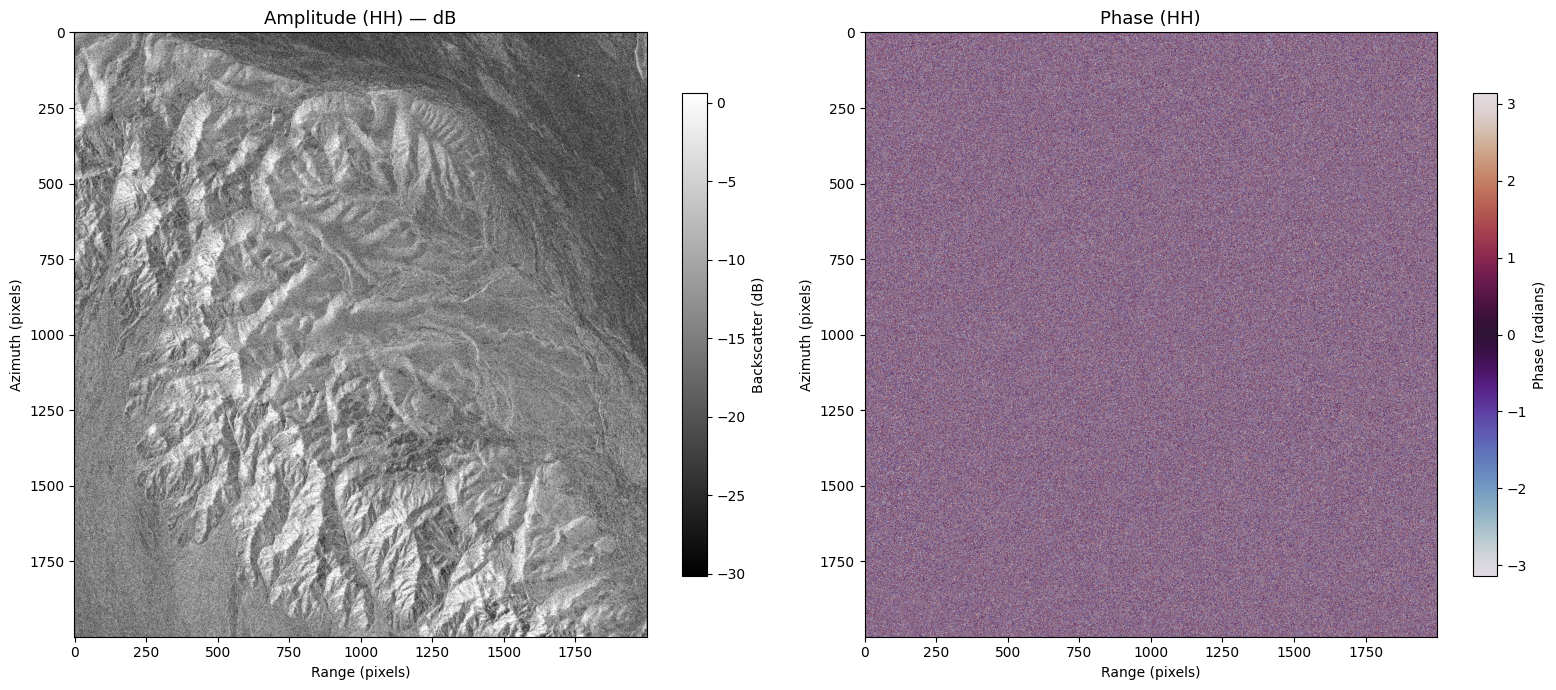

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Amplitude (dB)
vmin_db, vmax_db = np.nanpercentile(amplitude_db[amplitude_db > -100], [2, 98])
im0 = axes[0].imshow(amplitude_db, cmap='gray', vmin=vmin_db, vmax=vmax_db, aspect='auto')
axes[0].set_title(f'Amplitude ({POL}) — dB', fontsize=13)
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im0, ax=axes[0], label='Backscatter (dB)', shrink=0.8)

# Phase
im1 = axes[1].imshow(phase, cmap='twilight', vmin=-np.pi, vmax=np.pi, aspect='auto')
axes[1].set_title(f'Phase ({POL})', fontsize=13)
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[1], label='Phase (radians)', shrink=0.8)

plt.tight_layout()
plt.show()

#### Multi-polarisation comparison

If multiple polarisation channels are available, compare their amplitude response.

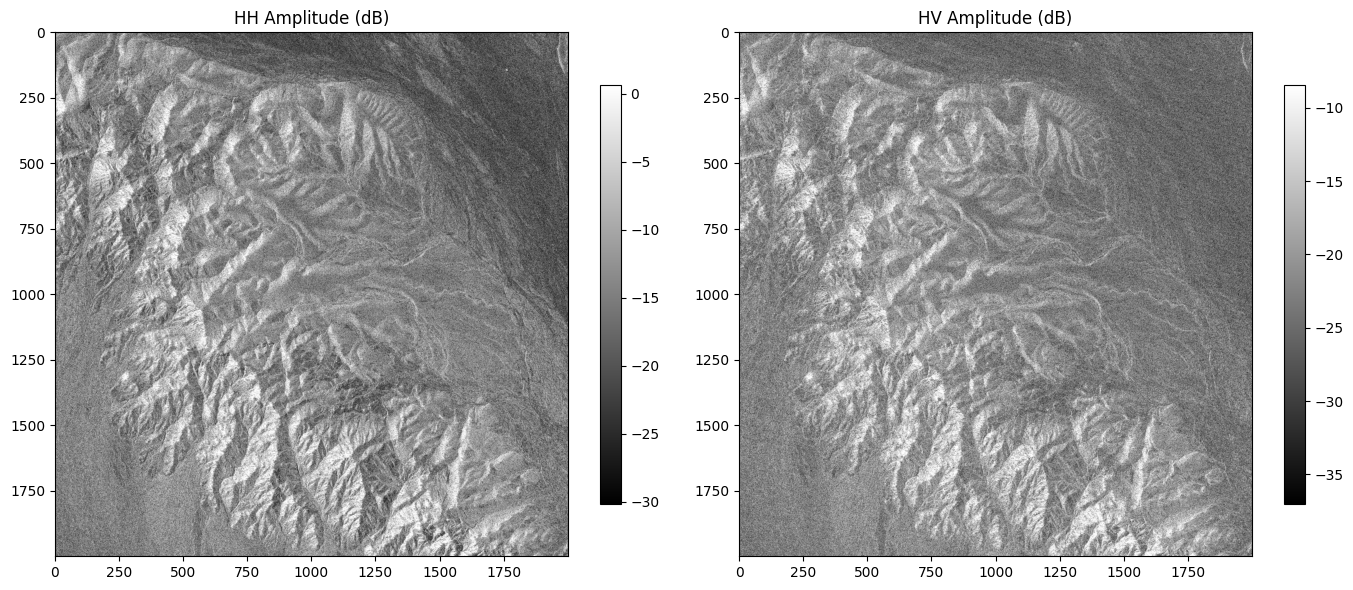

In [28]:
if len(pol_channels) > 1:
    n_pols = len(pol_channels)
    fig, axes = plt.subplots(1, n_pols, figsize=(7 * n_pols, 6))
    if n_pols == 1:
        axes = [axes]

    for ax, pol in zip(axes, pol_channels):
        pol_data = grid_group[pol][y_start:y_end, x_start:x_end]
        amp = np.abs(pol_data).astype(np.float32)
        amp_db = 10.0 * np.log10(amp**2 + eps)
        vmin_p, vmax_p = np.nanpercentile(amp_db[amp_db > -100], [2, 98])

        im = ax.imshow(amp_db, cmap='gray', vmin=vmin_p, vmax=vmax_p, aspect='auto')
        ax.set_title(f'{pol} Amplitude (dB)', fontsize=12)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Only one polarisation channel available ({pol_channels[0]}) — skipping comparison')

---
### Interferogram

An **interferogram** measures the phase difference between two SAR acquisitions over the same area. The interferometric phase encodes:
- **Topography** — related to terrain elevation
- **Surface displacement** — e.g., ground deformation from earthquakes
- **Atmospheric delay** — tropospheric/ionospheric path delay differences

The interferogram is formed by multiplying one SLC image by the complex conjugate of the other:

$$I = z_1 \cdot z_2^*$$

The **interferometric phase** is $\phi = \angle I$ and the **coherence** (a measure of signal quality) is estimated over a local window:

$$\gamma = \frac{|\langle z_1 \cdot z_2^* \rangle|}{\sqrt{\langle |z_1|^2 \rangle \cdot \langle |z_2|^2 \rangle}}$$

> **Note:** This is a simplified demonstration. A production InSAR workflow would include coregistration, flat-earth phase removal, topographic phase removal, filtering, and phase unwrapping. NISAR GSLC products are already geocoded, which simplifies coregistration but the scenes should overlap spatially.

In [29]:
heading('Loading Scene 2 for interferogram...')

# Open second GSLC file
file_objs_2 = earthaccess.open([granule_2])
f2 = h5py.File(file_objs_2[0], 'r')

# Read the same polarisation channel and window from scene 2
grid_group_2 = f2[GRID_BASE]
try:
    slc2_dataset = grid_group_2[POL]
    ny2, nx2 = slc2_dataset.shape
    print(f'Scene 2 {POL} full shape: {slc2_dataset.shape}')
    
    # Use same window (may need adjustment if scene geometries differ)
    y_start_2 = ny2 // 2 - WINDOW_SIZE // 2
    x_start_2 = nx2 // 2 - WINDOW_SIZE // 2
    slc2_data = slc2_dataset[y_start_2:y_start_2 + WINDOW_SIZE, x_start_2:x_start_2 + WINDOW_SIZE]
    print(f'Scene 2 subset shape: {slc2_data.shape}')
except KeyError:
    avail = [k for k in grid_group_2.keys() if k in ('HH', 'HV', 'VH', 'VV', 'RH', 'RV')]
    print(f'Channel {POL} not found in Scene 2. Available: {avail}')
    POL2 = avail[0]
    slc2_dataset = grid_group_2[POL2]
    ny2, nx2 = slc2_dataset.shape
    y_start_2 = ny2 // 2 - WINDOW_SIZE // 2
    x_start_2 = nx2 // 2 - WINDOW_SIZE // 2
    slc2_data = slc2_dataset[y_start_2:y_start_2 + WINDOW_SIZE, x_start_2:x_start_2 + WINDOW_SIZE]
    print(f'Using {POL2}. Subset shape: {slc2_data.shape}')

**Loading Scene 2 for interferogram...**

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 2763.05it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 18978.75it/s]


Scene 2 HH full shape: (68544, 69696)
Scene 2 subset shape: (2000, 2000)


In [30]:
# Ensure both subsets have the same shape (crop to common area if needed)
min_rows = min(slc_data.shape[0], slc2_data.shape[0])
min_cols = min(slc_data.shape[1], slc2_data.shape[1])

slc1_crop = slc_data[:min_rows, :min_cols]
slc2_crop = slc2_data[:min_rows, :min_cols]

print(f'Common grid size: {min_rows} × {min_cols}')

Common grid size: 2000 × 2000


In [31]:
heading('Computing interferogram...')

# Form interferogram
ifg = slc1_crop * np.conj(slc2_crop)

# Interferometric phase
ifg_phase = np.angle(ifg)

# Estimate coherence using a simple spatial averaging window
from scipy.ndimage import uniform_filter

WINDOW = 5  # pixels — averaging window for coherence estimation

# Spatial averages
avg_ifg = uniform_filter(ifg.real, WINDOW) + 1j * uniform_filter(ifg.imag, WINDOW)
avg_pow1 = uniform_filter(np.abs(slc1_crop)**2, WINDOW)
avg_pow2 = uniform_filter(np.abs(slc2_crop)**2, WINDOW)

# Coherence
coherence = np.abs(avg_ifg) / (np.sqrt(avg_pow1 * avg_pow2) + eps)
coherence = np.clip(coherence, 0, 1)

print(f'Coherence — mean: {np.nanmean(coherence):.3f}, median: {np.nanmedian(coherence):.3f}')

**Computing interferogram...**

Coherence — mean: 0.841, median: 0.884


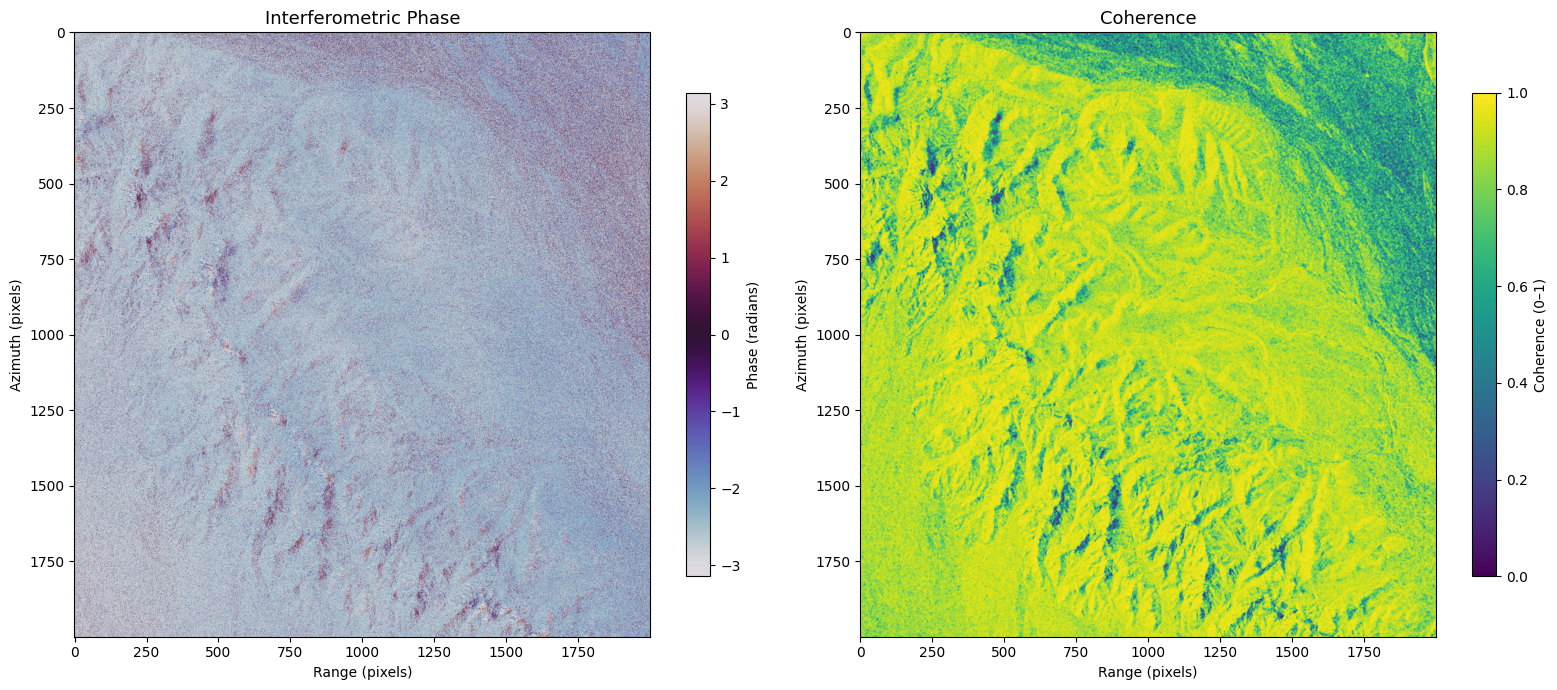

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Interferometric phase
im0 = axes[0].imshow(ifg_phase, cmap='twilight', vmin=-np.pi, vmax=np.pi, aspect='auto')
axes[0].set_title('Interferometric Phase', fontsize=13)
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im0, ax=axes[0], label='Phase (radians)', shrink=0.8)

# Coherence
im1 = axes[1].imshow(coherence, cmap='viridis', vmin=0, vmax=1, aspect='auto')
axes[1].set_title('Coherence', fontsize=13)
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[1], label='Coherence (0–1)', shrink=0.8)

plt.tight_layout()
plt.show()

**Interpreting the results:**
- **Interferometric phase fringes** appear as colour cycles. Each full cycle ($2\pi$) corresponds to a half-wavelength of displacement (L-band λ ≈ 24 cm → ~12 cm per fringe) or topographic relief.
- **High coherence** (yellow/green, near 1.0) indicates stable scatterers — typically bare rock, urban areas, or infrastructure.
- **Low coherence** (purple/blue, near 0.0) indicates temporal decorrelation — vegetation, water, or surface changes between acquisitions.

---
### Export to GeoTIFF

Complex SLC data cannot be directly stored in a standard GeoTIFF. We export the **amplitude** (in dB) as a single-band GeoTIFF. For the full complex data, consider exporting real and imaginary parts as separate bands, or saving as NetCDF.

In [33]:
import rioxarray  # noqa: F401 — registers the .rio accessor on xarray

# Create amplitude DataArray with spatial coordinates
amp_xr = xr.DataArray(
    data=amplitude_db,
    dims=['y', 'x'],
    coords=slc_xr.coords,
    name='amplitude_db',
    attrs={'units': 'dB', 'long_name': f'NISAR GSLC {POL} amplitude (dB)'}
)

# Set CRS and spatial dims for export
amp_xr = amp_xr.rio.write_crs(f'EPSG:{epsg}')
amp_xr = amp_xr.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Export
output_path = 'nisar_gslc_amplitude.tif'
amp_xr.rio.to_raster(output_path)
print(f'Exported amplitude to: {output_path}')

Exported amplitude to: nisar_gslc_amplitude.tif


---
### Clean up

Close the HDF5 file handles.

In [34]:
f1.close()
f2.close()
print('HDF5 files closed')

HDF5 files closed


---

**Additional resources:**
- [NISAR Mission (NASA/JPL)](https://nisar.jpl.nasa.gov/)
- [ASF NISAR Data Products](https://asf.alaska.edu/nisar/)
- [NISAR Science Users Handbook](https://nisar.jpl.nasa.gov/documents/)
- [earthaccess documentation](https://earthaccess.readthedocs.io/)
- [ASF Vertex Search](https://search.asf.alaska.edu/) — browse and discover NISAR data interactively